# Выбор локации для скважины

Допустим, вы работаете в добывающей компании «ГлавРосГосНефть». Нужно решить, где бурить новую скважину.

Вам предоставлены пробы нефти в трёх регионах: в каждом 100 000 месторождений, где измерили качество нефти и объём её запасов. Постройте модель машинного обучения, которая поможет определить регион, где добыча принесёт наибольшую прибыль. Проанализируйте возможную прибыль и риски техникой *Bootstrap.*

Шаги для выбора локации:

- В избранном регионе ищут месторождения, для каждого определяют значения признаков;
- Строят модель и оценивают объём запасов;
- Выбирают месторождения с самым высокими оценками значений. Количество месторождений зависит от бюджета компании и стоимости разработки одной скважины;
- Прибыль равна суммарной прибыли отобранных месторождений.

**Описание данных**

- `id` — уникальный идентификатор сотрудника;
- `dept` — отдел, в котором работает сотрудник;
- `level` — уровень занимаемой должности;
- `workload` — уровень загруженности сотрудника;
- `employment_years` — длительность работы в компании (в годах);
- `last_year_promo` — показывает, было ли повышение за последний год;
- `last_year_violations` — показывает, нарушал ли сотрудник трудовой договор за последний год;
- `supervisor_evaluation` — оценка качества работы сотрудника, которую дал руководитель;
- `salary` — ежемесячная зарплата сотрудника;
- `job_satisfaction_rate` — уровень удовлетворённости сотрудника работой в компании, целевой признак.

In [23]:
# импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.random import RandomState

from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.metrics import mean_squared_error


try:
    import phik
except:
    !pip install phik -q
    import phik


import warnings
#warnings.filterwarnings('ignore')

## Загрузка и подготовка данных

### Загрузка данных

In [24]:
geo_data_0 = pd.read_csv('/datasets/geo_data_0.csv')
geo_data_1 = pd.read_csv('/datasets/geo_data_1.csv')
geo_data_2 = pd.read_csv('/datasets/geo_data_2.csv')

In [25]:
for df in [geo_data_0, geo_data_1, geo_data_2]:
    display(df.head())

,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647


,id,f0,f1,f2,product
0,kBEdx,-15.001348,-8.276000,-0.005876,3.179103
1,62mP7,14.272088,-3.475083,0.999183,26.953261
2,vyE1P,6.263187,-5.948386,5.001160,134.766305
3,KcrkZ,-13.081196,-11.506057,4.999415,137.945408
4,AHL4O,12.702195,-8.147433,5.004363,134.766305


,id,f0,f1,f2,product
0,fwXo0,-1.146987,0.963328,-0.828965,27.758673
1,WJtFt,0.262778,0.269839,-2.530187,56.069697
2,ovLUW,0.194587,0.289035,-5.586433,62.871910
3,q6cA6,2.236060,-0.553760,0.930038,114.572842
4,WPMUX,-0.515993,1.716266,5.899011,149.600746


Выведем общую информацию о таблицах

In [26]:
for df in [geo_data_0, geo_data_1, geo_data_2]:
    df.info()
    print('\n/---------------/\n')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB

/---------------/

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB

/---------------/

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (t

Предварительно проблем в данных не наблюдается

### Предобработка данных

#### Дубликаты в id

In [27]:
print('Кол-во дубликатов id в таблицах:')
for df in [geo_data_0, geo_data_1, geo_data_2]:
    display(df['id'].duplicated().sum())
    
for df in [geo_data_0, geo_data_1, geo_data_2]:
    display(df[df['id'].duplicated(keep=False)].sort_values('id'))

Кол-во дубликатов id в таблицах:


10

4

4

,id,f0,f1,f2,product
66136,74z30,1.084962,-0.312358,6.990771,127.643327
64022,74z30,0.741456,0.459229,5.153109,140.771492
51970,A5aEY,-0.180335,0.935548,-2.094773,33.020205
3389,A5aEY,-0.039949,0.156872,0.209861,89.249364
69163,AGS9W,-0.933795,0.116194,-3.655896,19.230453
42529,AGS9W,1.454747,-0.479651,0.683380,126.370504
931,HZww2,0.755284,0.368511,1.863211,30.681774
7530,HZww2,1.061194,-0.373969,10.430210,158.828695
63593,QcMuo,0.635635,-0.473422,0.862670,64.578675
1949,QcMuo,0.506563,-0.323775,-2.215583,75.496502


,id,f0,f1,f2,product
5849,5ltQ6,-3.435401,-12.296043,1.999796,57.085625
84461,5ltQ6,18.213839,2.191999,3.993869,107.813044
1305,LHZR0,11.170835,-1.945066,3.002872,80.859783
41906,LHZR0,-8.989672,-4.286607,2.009139,57.085625
2721,bfPNe,-9.494442,-5.463692,4.006042,110.992147
82178,bfPNe,-6.202799,-4.820045,2.995107,84.038886
47591,wt4Uk,-9.091098,-8.109279,-0.002314,3.179103
82873,wt4Uk,10.259972,-9.376355,4.994297,134.766305


,id,f0,f1,f2,product
45404,KUPhW,0.231846,-1.698941,4.990775,11.716299
55967,KUPhW,1.211150,3.176408,5.543540,132.831802
11449,VF7Jo,2.122656,-0.858275,5.746001,181.716817
49564,VF7Jo,-0.883115,0.560537,0.723601,136.233420
44378,Vcm5J,-1.229484,-2.439204,1.222909,137.968290
95090,Vcm5J,2.587702,1.986875,2.482245,92.327572
28039,xCHr8,1.633027,0.368135,-2.378367,6.120525
43233,xCHr8,-0.847066,2.101796,5.597130,184.388641


В каждой таблице есть строки, в которых дублируются id, но не дублируются все остальные значения

Удалим эти строки

In [28]:
geo_data_0 = geo_data_0.drop_duplicates(subset=['id'], keep=False)
geo_data_1 = geo_data_1.drop_duplicates(subset=['id'], keep=False)
geo_data_2 = geo_data_2.drop_duplicates(subset=['id'], keep=False)

print('Кол-во дубликатов по id:')
for df in [geo_data_0, geo_data_1, geo_data_2]:
    display(df['id'].duplicated().sum())

Кол-во дубликатов по id:


0

0

0

Установим столбец `id` в качестве индекса

In [29]:
geo_data_0 = geo_data_0.set_index('id')
geo_data_1 = geo_data_1.set_index('id')
geo_data_2 = geo_data_2.set_index('id')

#### Дубликаты строк

In [30]:
print("Кол-во строк-дубликатов:")
for df in [geo_data_0, geo_data_1, geo_data_2]:
    display(df.duplicated().sum())

Кол-во строк-дубликатов:


0

0

0

Строк-дубликатов нет

#### Обработка пропусков

In [31]:
print("Кол-во пропусков:")
for df in [geo_data_0, geo_data_1, geo_data_2]:
    display(df.isna().sum())

Кол-во пропусков:


f0         0
f1         0
f2         0
product    0
dtype: int64

f0         0
f1         0
f2         0
product    0
dtype: int64

f0         0
f1         0
f2         0
product    0
dtype: int64

Пропусков нет

#### Вывод

Из проблем в данных были замечены дубликаты по столбцу `id`. Такие строки были удалены

## Исследовательский анализ данных

In [32]:
# функция вывода характеристик количественного признака
def feature_stat(feature, title, ylabel):
    fig, axes = plt.subplots(ncols=1, nrows=2, gridspec_kw={'height_ratios' : [15, 85]}, figsize=(8, 5), sharex=True)
    axes[0].boxplot(feature, vert=False)
    axes[0].set_title(title)
    
    axes[1].hist(feature, bins=50)
    axes[1].set_ylabel(ylabel)
    axes[1].axvline(feature.mean(), color='red', linestyle='-', linewidth=2, label=f'Среднее: {feature.mean():.2f}')
    axes[1].axvline(feature.median(), color='red', linestyle='--', linewidth=2, label=f'Медиана: {feature.median():.2f}')
    
    plt.tight_layout()
    plt.legend()
    plt.grid()
    plt.show()
    print(feature.describe().T)

### Регион 1

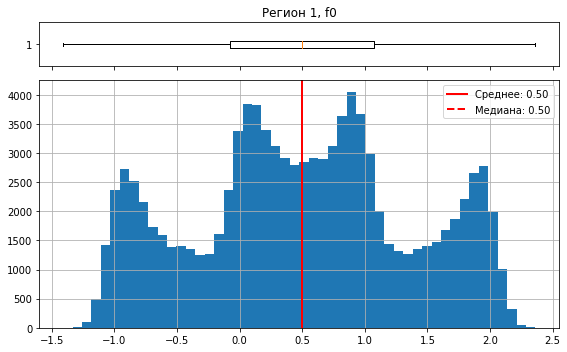

count    99980.000000
mean         0.500447
std          0.871879
min         -1.408605
25%         -0.072674
50%          0.502374
75%          1.073692
max          2.362331
Name: f0, dtype: float64


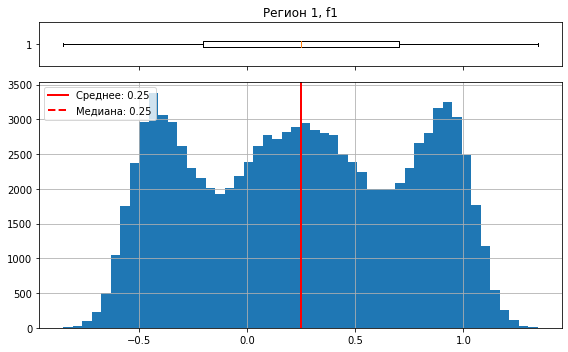

count    99980.000000
mean         0.250147
std          0.504431
min         -0.848218
25%         -0.200869
50%          0.250252
75%          0.700646
max          1.343769
Name: f1, dtype: float64


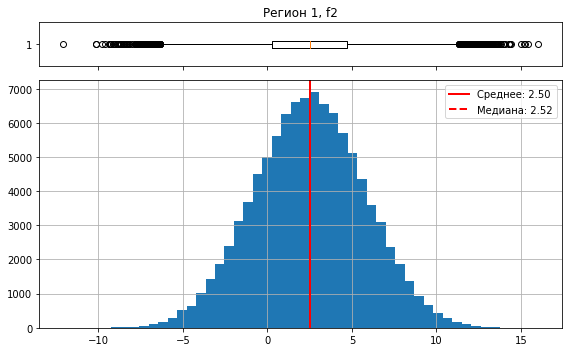

count    99980.000000
mean         2.502638
std          3.248056
min        -12.088328
25%          0.288010
50%          2.516005
75%          4.714884
max         16.003790
Name: f2, dtype: float64


In [33]:
feature_stat(geo_data_0['f0'], 'Регион 1, f0', '')
feature_stat(geo_data_0['f1'], 'Регион 1, f1', '')
feature_stat(geo_data_0['f2'], 'Регион 1, f2', '')

Графики напоминают нормальные с множественными пиками

### Регион 2

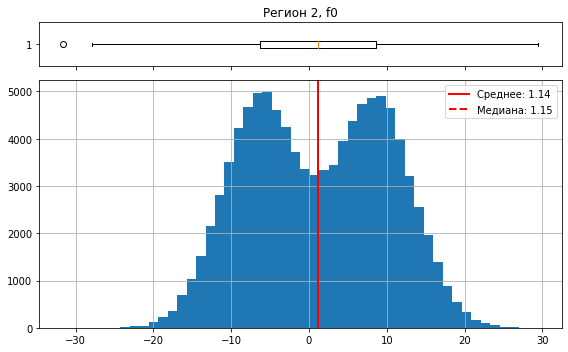

count    99992.000000
mean         1.141363
std          8.965805
min        -31.609576
25%         -6.298525
50%          1.153190
75%          8.620964
max         29.421755
Name: f0, dtype: float64


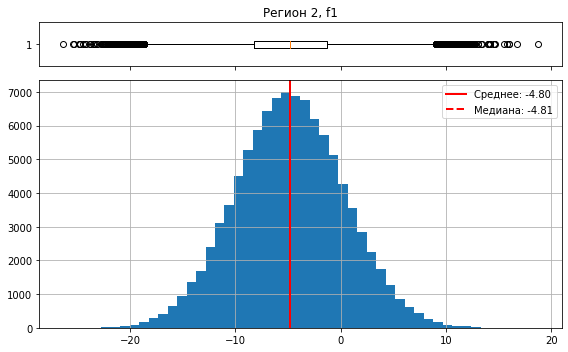

count    99992.000000
mean        -4.796522
std          5.119934
min        -26.358598
25%         -8.267985
50%         -4.813005
75%         -1.332704
max         18.734063
Name: f1, dtype: float64


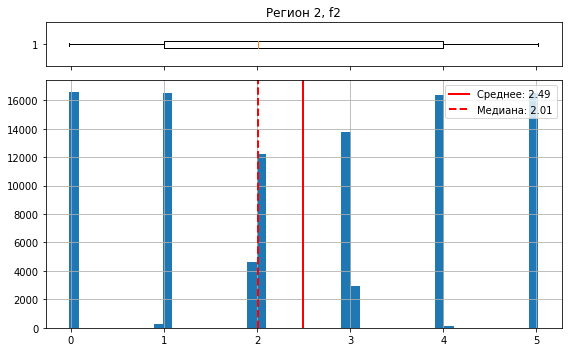

count    99992.000000
mean         2.494511
std          1.703587
min         -0.018144
25%          1.000021
50%          2.011475
75%          3.999904
max          5.019721
Name: f2, dtype: float64


In [34]:
feature_stat(geo_data_1['f0'], 'Регион 2, f0', '')
feature_stat(geo_data_1['f1'], 'Регион 2, f1', '')
feature_stat(geo_data_1['f2'], 'Регион 2, f2', '')

Графики `f0` и `f1` нормальные, а `f2` практически дискретный признак.

### Регион 3

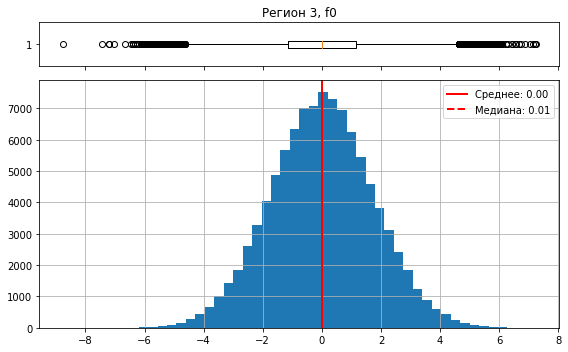

count    99992.000000
mean         0.001975
std          1.732061
min         -8.760004
25%         -1.162328
50%          0.009411
75%          1.158442
max          7.238262
Name: f0, dtype: float64


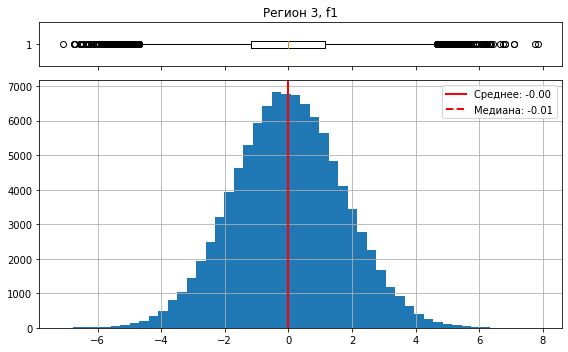

count    99992.000000
mean        -0.002113
std          1.730404
min         -7.084020
25%         -1.174820
50%         -0.009580
75%          1.163592
max          7.844801
Name: f1, dtype: float64


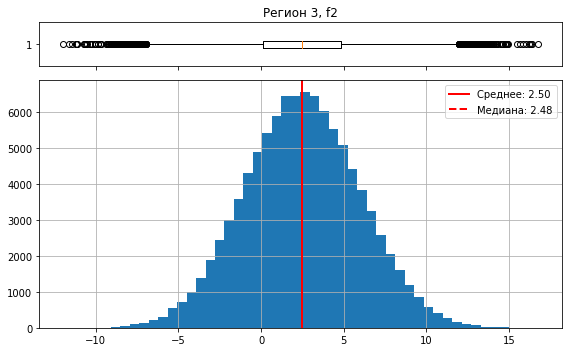

count    99992.000000
mean         2.495088
std          3.473491
min        -11.970335
25%          0.130269
50%          2.484236
75%          4.858662
max         16.739402
Name: f2, dtype: float64


In [35]:
feature_stat(geo_data_2['f0'], 'Регион 3, f0', '')
feature_stat(geo_data_2['f1'], 'Регион 3, f1', '')
feature_stat(geo_data_2['f2'], 'Регион 3, f2', '')

Все графики нормальные

### Вывод

Из проблем замечен только признак `f2` во втором регионе, его распределение напоминает дискретный признак.

## Корреляционный анализ

Регион 1


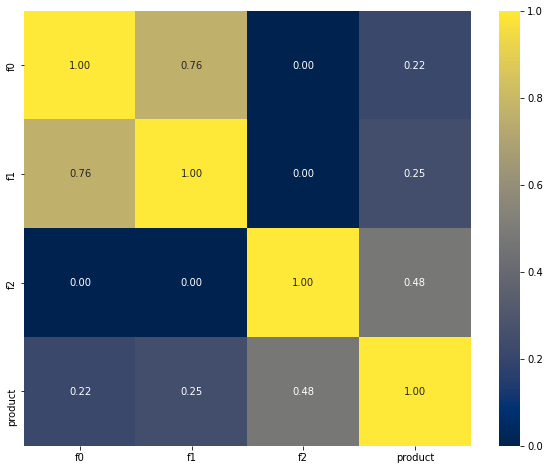

Регион 2


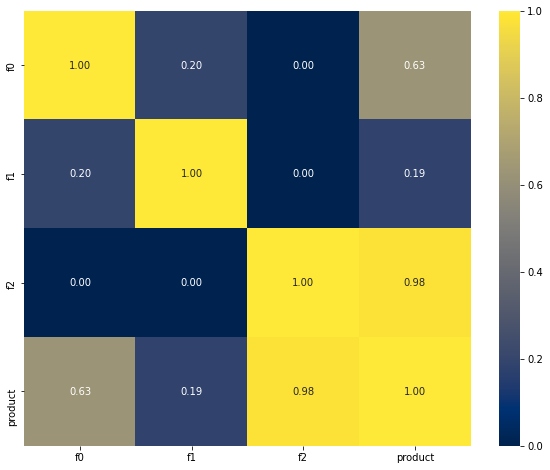

Регион 3


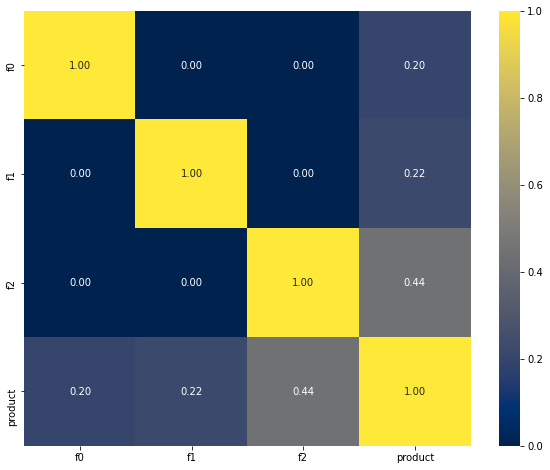

In [36]:
print('Регион 1')
plt.figure(figsize=(10, 8))
sns.heatmap(geo_data_0.phik_matrix(interval_cols=
                                             geo_data_0.select_dtypes(include='number').columns
                                            ), annot=True, fmt='.2f', cmap='cividis')
plt.show()

print('Регион 2')
plt.figure(figsize=(10, 8))
sns.heatmap(geo_data_1.phik_matrix(interval_cols=
                                             geo_data_1.select_dtypes(include='number').columns
                                            ), annot=True, fmt='.2f', cmap='cividis')
plt.show()

print('Регион 3')
plt.figure(figsize=(10, 8))
sns.heatmap(geo_data_2.phik_matrix(interval_cols=
                                             geo_data_2.select_dtypes(include='number').columns
                                            ), annot=True, fmt='.2f', cmap='cividis')
plt.show()

Во втором регионе замечена весьма высокая корреляция признака `f2` с целевым признаком, следовательно есть мультиколлинеарность

## Обучение и проверка модели

### Обучение моделей

In [37]:
RANDOM_STATE = 74

# функция для обучения модели по данным региона
def make_model(df):
    # разбиваем на выборки
    X_train, X_valid, y_train, y_valid = train_test_split(
        df.drop(['product'], axis=1),
        df['product'],
        random_state=RANDOM_STATE
    )
    
    # стандартизируем
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_valid = scaler.transform(X_valid)
    
    # оценка на кросс-валидации
    model = LinearRegression()
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
    print(f'Оценка на кросс-валидации: {-round(scores.mean(), 3)}')
    
    # обучение
    model.fit(X_train, y_train)
    preds = pd.Series(model.predict(X_valid), index=y_valid.index)
    print(f'RMSE на валидационной выборке (средняя ошибка): {round(mean_squared_error(y_valid, preds, squared=False), 3)} тыс. баррелей')
    
    # рассчёт среднего предсказанного запаса сырья
    oil_mean = preds.mean()
    print(f'Средний запас предсказанного сырья: {round(oil_mean, 3)} тыс. баррелей')
    
    return preds, y_valid, model, oil_mean

In [38]:
print('Регион 1:')
preds0, test_vals0, model0, oil_mean0 = make_model(geo_data_0)
print('\nРегион 2:')
#preds1, test_vals1, model1, oil_mean1 = make_model(geo_data_1.drop('f2', axis=1))
preds1, test_vals1, model1, oil_mean1 = make_model(geo_data_1)
print('\nРегион 3:')
preds2, test_vals2, model2, oil_mean2 = make_model(geo_data_2)

Регион 1:
Оценка на кросс-валидации: 37.718
RMSE на валидационной выборке (средняя ошибка): 37.623 тыс. баррелей
Средний запас предсказанного сырья: 92.394 тыс. баррелей

Регион 2:
Оценка на кросс-валидации: 0.892
RMSE на валидационной выборке (средняя ошибка): 0.885 тыс. баррелей
Средний запас предсказанного сырья: 68.635 тыс. баррелей

Регион 3:
Оценка на кросс-валидации: 40.077
RMSE на валидационной выборке (средняя ошибка): 39.988 тыс. баррелей
Средний запас предсказанного сырья: 94.989 тыс. баррелей


### Вывод

- Для каждого региона была обучена модель линейной регресси для предсказания количества нефти в скважине.

- В третьем регионе самой большой средний запас предсказанного сырья, самый маленький во втором.

- Во втором регионе самый большой показатель метрики RMSE, самый маленький в первом.

## Подготовка к расчёту прибыли

In [39]:
PRODUCT_PRICE = 450000 # цена в рублях за единицу продукта (тыс. баррелей)
BUDGET = 1e10 # бюджет в рублях на разработку скважин в регионе

Чтобы окупить бюджет, нужно чтобы общая прибыль с нефти превысила бюджет.

Рассчитаем это значение, а также минимальное среднее значение продукта для скважены

In [40]:
BOOTSTRAP_COUNT = 1000
SAMPLE_SIZE = 500

MIN_TOTAL_OIL_COUNT = BUDGET / PRODUCT_PRICE
WELL_COUNT = 200 # кол-во скважин
MIN_WELL_OIL_COUNT = MIN_TOTAL_OIL_COUNT / WELL_COUNT
print(f'Чтобы окупить бюджет, нужно добыть {round(MIN_TOTAL_OIL_COUNT, 3)} ед. продукта (тыс. баррелей)')
print(f'Одна скважина минимально в среднем должна приносить {round(MIN_WELL_OIL_COUNT, 3)} ед. продукта (тыс. баррелей)')

Чтобы окупить бюджет, нужно добыть 22222.222 ед. продукта (тыс. баррелей)
Одна скважина минимально в среднем должна приносить 111.111 ед. продукта (тыс. баррелей)


### Вывод

Среднего запаса предсказанного сырья не хватает для окупа бюджета

## Расчёт прибыли и рисков 

Среднее значение продукта на скажинах меньше минимального среднего, необходимого для окупа бюджета

Напишем функцию, рассчитывающую прибыль в регионе. Она будет брать 200 самых продуктивных скважин.

In [41]:
def region_revenue(preds, target, count):
    preds_sorted = preds.sort_values(ascending=False)
    selected = target[preds_sorted.index][:count]
    return round(selected.sum() * PRODUCT_PRICE - BUDGET, 3)

Найдём распределение прибыли в регионах техникой Bootstrap. Будем брать 500 случайных месторождений и из них выбирать 200 самых продуктивных

In [42]:
state = RandomState(RANDOM_STATE)

revenue_distribution0 = np.array([])
revenue_distribution1 = np.array([])
revenue_distribution2 = np.array([])

for i in range(BOOTSTRAP_COUNT):
    revenue_distribution0 = np.append(revenue_distribution0, region_revenue(preds0.sample(SAMPLE_SIZE, random_state=state),
                                                                            test_vals0, 200))
    revenue_distribution1 = np.append(revenue_distribution1, region_revenue(preds1.sample(SAMPLE_SIZE, random_state=state),
                                                                           test_vals1, 200))
    revenue_distribution2 = np.append(revenue_distribution2, region_revenue(preds2.sample(SAMPLE_SIZE, random_state=state),
                                                                           test_vals2, 200))

### Bootstrap

Найдём среднюю прибыль, 95% доверительный интервал и вероятность убытков (прибыль меньше 10 млрд.) по регионам по данным Bootstrap'а

In [44]:
print(f'Средняя прибыль в регионе 1: {round(sum(revenue_distribution0) / len(revenue_distribution0), 3)} рублей')
print(f'95% доверительный интервал среднего: [{round(np.quantile(revenue_distribution0, 0.025), 3)}; {round(np.quantile(revenue_distribution0, 0.975),3)}]')
print(f'Вероятность убытков: {round(len(revenue_distribution0[revenue_distribution0<0]) / len(revenue_distribution0) * 100, 2)}%')
print('')
print(f'Средняя прибыль в регионе 2: {round(sum(revenue_distribution1) / len(revenue_distribution1), 3)} рублей')
print(f'95% доверительный интервал среднего: [{round(np.quantile(revenue_distribution1, 0.025), 3)}; {round(np.quantile(revenue_distribution1, 0.975),3)}]')
print(f'Вероятность убытков: {round(len(revenue_distribution1[revenue_distribution1<0]) / len(revenue_distribution1) * 100, 3)}%')
print('')
print(f'Средняя прибыль в регионе 3: {round(sum(revenue_distribution2) / len(revenue_distribution2), 3)} рублей')
print(f'95% доверительный интервал среднего: [{round(np.quantile(revenue_distribution2, 0.025), 3)}; {round(np.quantile(revenue_distribution2, 0.975),3)}]')
print(f'Вероятность убытков: {len(revenue_distribution2[revenue_distribution2<0]) / len(revenue_distribution2) * 100}%')

Средняя прибыль в регионе 1: 402389945.744 рублей
95% доверительный интервал среднего: [-116831407.924; 867637949.945]
Вероятность убытков: 6.6%

Средняя прибыль в регионе 2: 425348057.531 рублей
95% доверительный интервал среднего: [58156194.119; 813102003.986]
Вероятность убытков: 0.9%

Средняя прибыль в регионе 3: 432177179.341 рублей
95% доверительный интервал среднего: [-97092550.915; 936487884.915]
Вероятность убытков: 5.7%


### Вывод

- Из всех регионов для разработки подходит только второй регион, так как в нём вероятность убытков меньше 2.5%

- Итого, для разработки выбираем второй регион.

## Вывод

По полученным данным была проведена следующая работа

**Предобработка данных**:

- Из проблем в данных были замечены дубликаты по столбцу `id`. Такие строки были удалены

**Корреляционный анализ**:

- Во втором регионе замечена весьма высокая корреляция признака `f2` с целевым признаком, следовательно при обучении признак `f2` нужно будет исключить

**Обучение модели**:

- Для каждого региона была обучена модель линейной регресси для предсказания количества нефти в скважине.

- В третьем регионе самой большой средний запас предсказанного сырья, самый маленький во втором.

- Во втором регионе самый большой показатель метрики RMSE, самый маленький в первом.

- Результаты обучения:

    Регион 1:
    - Оценка на кросс-валидации: 37.718
    - RMSE на валидационной выборке (средняя ошибка): 37.623 тыс. баррелей
    - Средний запас предсказанного сырья: 92.394 тыс. баррелей

    Регион 2:
    - Оценка на кросс-валидации: 45.924
    - RMSE на валидационной выборке (средняя ошибка): 45.925 тыс. баррелей
    - Средний запас предсказанного сырья: 68.887 тыс. баррелей

    Регион 3:
    - Оценка на кросс-валидации: 40.077
    - RMSE на валидационной выборке (средняя ошибка): 39.988 тыс. баррелей
    - Средний запас предсказанного сырья: 94.989 тыс. баррелей

**Подготовка к расчёту прибыли**:

- Чтобы окупить бюджет, нужно добыть 22222.222 ед. продукта (тыс. баррелей)

- Одна скважина минимально в среднем должна приносить 111.111 ед. продукта (тыс. баррелей)

- Среднего запаса предсказанного сырья не хватает для окупа бюджета

**Расчёт прибыли и рисков**:

Техникой Bootstrap были рассчитаны средняя прибыль в регионах, вероятность убытков и 95% доверительный интервал

Регион 1
- Средняя прибыль: 402389945.744 рублей
- 95% доверительный интервал среднего: [-116831407.924; 867637949.945]
- Вероятность убытков: 6.6%

Регион 2
- Средняя прибыль: 425348057.531 рублей
- 95% доверительный интервал среднего: [58156194.119; 813102003.986]
- Вероятность убытков: 0.9%

Регион 3
- Средняя прибыль в регионе 3: 432177179.341 рублей
95% доверительный интервал среднего: [-97092550.915; 936487884.915]
Вероятность убытков: 5.7%

Итого:

- Для разработки подходят первый и третий регионы так как в них низкая вероятность убытков
- В третьем регионе больше средняя прибыль, следовательно выбираем его